# 11.8 換圖後答對新圖，才能說用了圖片嗎？


四張圖是兩圓兩方；完全不看圖、永遠猜圓，只能答對一半。若資料改成九圓一方，同一規則就能得九成。先算這個固定猜測基準，才知道高分是否真的需要圖片。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

In [2]:
truth = ["circle", "square", "circle", "square"]
text_only = ["circle"] * len(truth)
accuracy = sum(a == b for a, b in zip(truth, text_only)) / len(truth)
print("平衡資料的固定猜測", accuracy)
imbalanced = ["circle"] * 9 + ["square"]
print("九比一資料的固定猜測", imbalanced.count("circle") / len(imbalanced))

平衡資料的固定猜測 0.5
九比一資料的固定猜測 0.9


前一組印 0.5，後一組印 0.9；變的是資料比例，不是模型。真模型還需成對檢查：固定「什麼形狀」，圓換成方時，希望答案 circle→square，並按換入圖的真值評分。


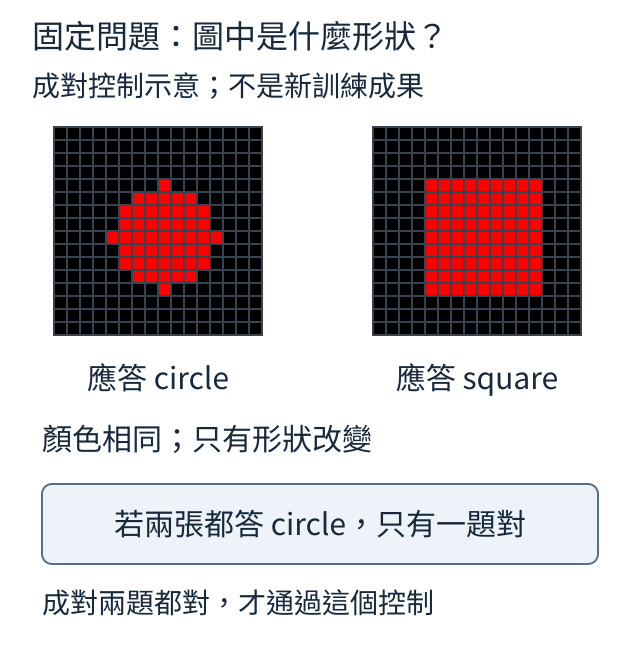

In [3]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-11-shape-pairs.svg")))

圖中展示既有六對形狀題的失敗模式：模型一直答 circle，原題和替圖各 3/6，兩端同時正確卻是 0/6。只看前後同樣一半，會漏掉它根本沒正確跟隨形狀。

遮圖是另一種檢查：移除像素但保留原答案，觀察原題成績對線索的依賴，稱消融。錯配圖片仍按原答案也是原答案一致率；改按新圖答案才是新圖正確率。兩者不能混報成同一能力。

既有介入中，顏色換圖後能跟著改對，例如紅圖換入綠圖回 green；形狀始終猜 circle。原圖總數 9/12 因而掩蓋不同線索的使用。遮圖後分數下降可以提供線索，成對回答按規則改對則更直接。

替換要改問題相關屬性。紅圓換藍圓，形狀答案本來不必變；不能把不變一律算沒看圖。練習為一張圓改成方，先寫應改的答案，再看模型；這比事後只說輸出不同更清楚。

<details>
<summary>回顧與查證</summary>

可回顧：[11.4答案依圖與問題](https://birdhackor.github.io/tiny-perceptron-vlm/11.4.html)、[11.1敏感不等於正確](https://birdhackor.github.io/tiny-perceptron-vlm/11.1.html)。

原實驗的資料切分、更新設定與逐題結果見[既有實報](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/vision_ablation.json)；重做入口見[實驗說明](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/README.md)。這是上述有限任務的歷史紀錄。

</details>
